# Hansard Sovereign — benchmark results

All measurements on a **4 GB RTX A2000 Laptop GPU** (a constrained, consumer-grade target). Each study's raw CSV lives in `results/` (or `finetune/`); this notebook loads them into pandas and plots the figures.

1. Quantization / model footprint · 2. Context length (prefill) · 3. KV cache compression · 4. Model load (NVMe→RAM→VRAM) · 5. QLoRA fine-tune


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
RED, BLUE, GREEN = "#c0504d", "#4f81bd", "#9bbb59"


## 1. Quantization / model footprint
Production 8B (q4_K_M) vs a fully-resident 1.5B on the 4 GB GPU.


In [2]:
q = pd.read_csv("results/quantization_benchmark.csv")
quant = (q.groupby("model")
          .agg(tokens_per_sec=("tokens_per_sec", "mean"),
               ttft_ms=("ttft_ms", "mean"),
               peak_vram_mb=("peak_vram_mb", "max"),
               processor=("processor", "first"))
          .round(1))
quant


,tokens_per_sec,ttft_ms,peak_vram_mb,processor
model,,,,
llama3.1:8b-instruct-q4_K_M,5.7,1789.1,2359,58%/42% CPU/GPU
qwen2.5:1.5b,85.3,623.1,1219,100% GPU


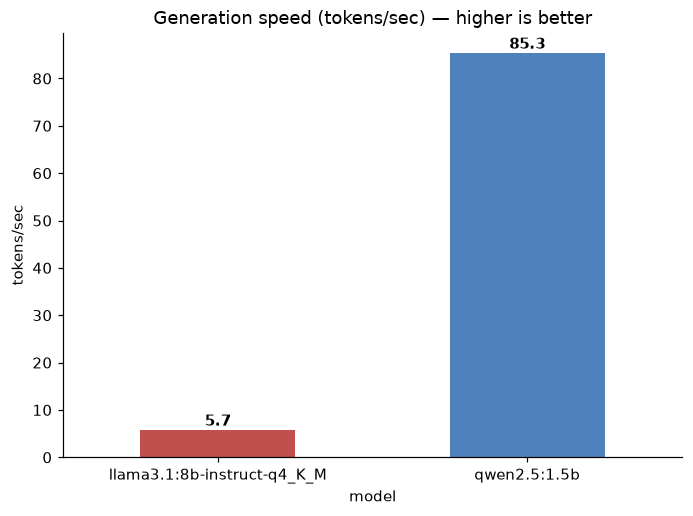

In [3]:
ax = quant["tokens_per_sec"].plot.bar(color=[RED, BLUE], rot=0,
        title="Generation speed (tokens/sec) — higher is better")
ax.set_ylabel("tokens/sec")
for i, v in enumerate(quant["tokens_per_sec"]):
    ax.text(i, v + 1, f"{v:.1f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()


## 2. Context length → prefill latency
How prompt length (retrieved-doc count `N`) drives prefill (TTFT). Measured on the GPU-resident 1.5B to isolate the scaling.


In [4]:
c = pd.read_csv("results/context_length_benchmark.csv")
ctx = (c.groupby("n_results")
        .agg(prompt_tokens=("prompt_tokens", "mean"),
             prefill_ms=("prompt_eval_ms", "mean"),
             total_ms=("total_time_ms", "mean"),
             peak_vram_mb=("peak_vram_mb", "max"))
        .round(0).astype(int))
ctx


,prompt_tokens,prefill_ms,total_ms,peak_vram_mb
n_results,,,,
3,984,253,1517,1529
5,1440,304,2292,1529
10,2520,554,2716,1529
20,4787,1187,2864,1529
30,6909,1893,2868,1529
50,11465,3562,5065,1529


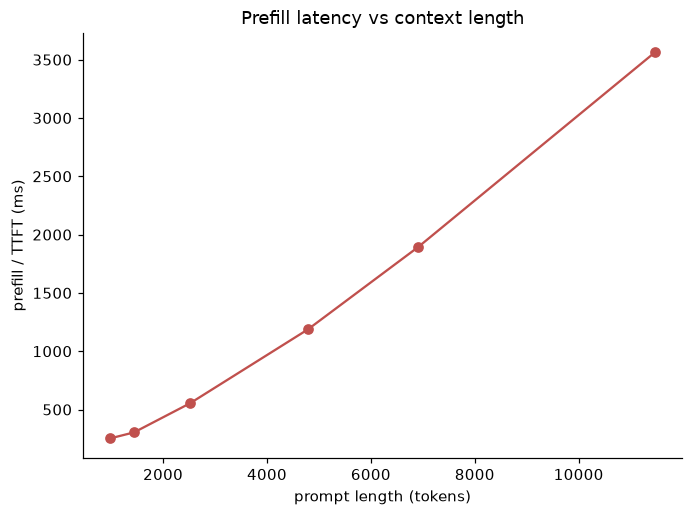

In [5]:
ax = ctx.plot(x="prompt_tokens", y="prefill_ms", marker="o", color=RED,
              legend=False, title="Prefill latency vs context length")
ax.set_xlabel("prompt length (tokens)"); ax.set_ylabel("prefill / TTFT (ms)")
plt.tight_layout(); plt.show()


## 3. KV cache compression
`OLLAMA_KV_CACHE_TYPE` f16 / q8_0 / q4_0 (flash attention on). Loaded size = model + KV cache.


In [6]:
k = pd.read_csv("results/kv_cache_benchmark.csv")
k["size_gb"] = k["loaded_size"].str.extract(r"([\d.]+)").astype(float)
kv = (k.pivot_table(index="model", columns="kv_cache_type", values="size_gb")
       .reindex(columns=["f16", "q8_0", "q4_0"]))
kv


kv_cache_type,f16,q8_0,q4_0
model,,,
llama3.1:8b-instruct-q4_K_M,6.2,5.7,5.4
qwen2.5:1.5b,1.6,1.4,1.3


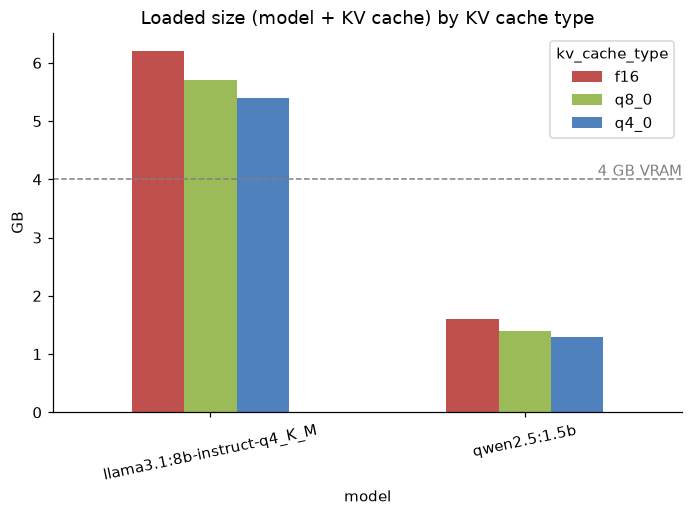

In [7]:
ax = kv.plot.bar(color=[RED, GREEN, BLUE], rot=12,
                 title="Loaded size (model + KV cache) by KV cache type")
ax.set_ylabel("GB"); ax.axhline(4.0, ls="--", color="gray", lw=1)
ax.text(ax.get_xlim()[1], 4.0, " 4 GB VRAM", va="bottom", ha="right", color="gray")
plt.tight_layout(); plt.show()


## 4. Model load: NVMe → system RAM → VRAM
Run 0 is a cold load (from NVMe); later runs are page-cache-warm (RAM→VRAM). Their difference is the NVMe read penalty.


In [8]:
n = pd.read_csv("results/nvme_load_benchmark.csv")
size = n.groupby("model")["size_mb"].first().rename("size_mb")
cold = n[n.run == 0].set_index("model")["load_ms"].rename("cold_ms")
warm = n[n.run > 0].groupby("model")["load_ms"].mean().rename("warm_ms")
nv = pd.concat([size, warm, cold], axis=1).round(0)
nv["nvme_penalty_ms"] = (nv.cold_ms - nv.warm_ms).clip(lower=0).round(0)
nv = nv.sort_values("size_mb")
nv


,size_mb,warm_ms,cold_ms,nvme_penalty_ms
model,,,,
hansard-qwen,940.0,1890.0,1755.0,0.0
qwen2.5:1.5b,940.0,1892.0,3268.0,1376.0
qwen2.5:7b-instruct,4466.0,4428.0,11786.0,7358.0
llama3.1:8b-instruct-q4_K_M,4693.0,5118.0,17932.0,12814.0


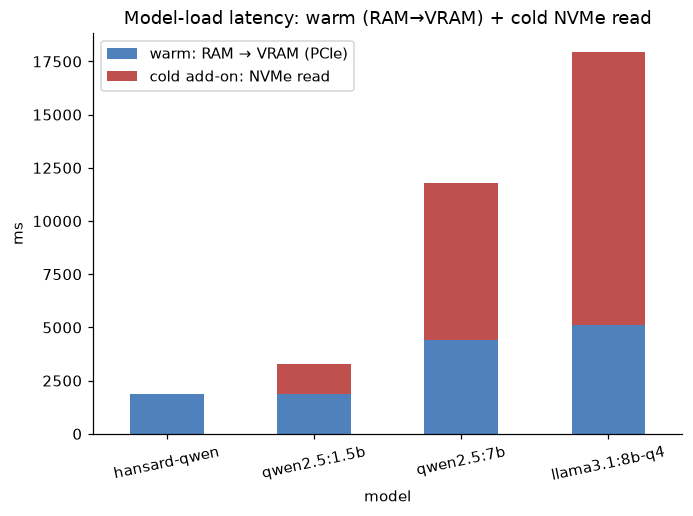

In [9]:
labels = [m.replace("-instruct-q4_K_M", "-q4").replace("-instruct", "") for m in nv.index]
ax = nv[["warm_ms", "nvme_penalty_ms"]].plot.bar(
        stacked=True, color=[BLUE, RED], rot=12,
        title="Model-load latency: warm (RAM→VRAM) + cold NVMe read")
ax.set_xticklabels(labels); ax.set_ylabel("ms")
ax.legend(["warm: RAM → VRAM (PCIe)", "cold add-on: NVMe read"])
plt.tight_layout(); plt.show()


## 5. QLoRA fine-tune — native citation-format adherence
Held-out queries, raw output, no Python post-processing. Base 1.5B vs the QLoRA fine-tune.


In [10]:
e = pd.read_csv("finetune/eval_results.csv")
rate = pd.DataFrame({
    "model": ["qwen2.5:1.5b (base)", "hansard-qwen (QLoRA)"],
    "well_formatted": [int(e.base_ok.sum()), int(e.ft_ok.sum())],
    "n": [len(e), len(e)],
})
rate["pct"] = (100 * rate.well_formatted / rate.n).round(0)
rate


,model,well_formatted,n,pct
0,qwen2.5:1.5b (base),1,14,7.0
1,hansard-qwen (QLoRA),14,14,100.0


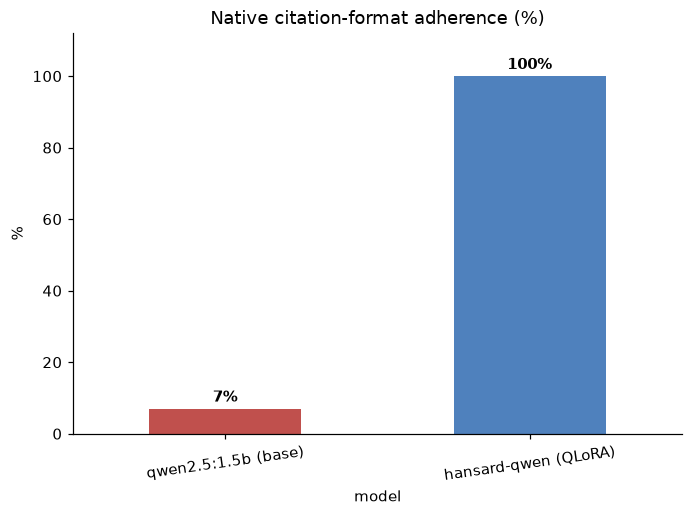

In [11]:
ax = rate.set_index("model")["pct"].plot.bar(color=[RED, BLUE], rot=8,
        title="Native citation-format adherence (%)")
ax.set_ylabel("%"); ax.set_ylim(0, 112)
for i, v in enumerate(rate["pct"]):
    ax.text(i, v + 2, f"{v:.0f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()


## Takeaways
- On 4 GB, whether a model **fits in VRAM** dominates throughput (15× 1.5B vs spilling 8B) and load cost (cold 8B: ~18 s, mostly NVMe read).
- **KV-cache compression** (q8_0) reclaims VRAM and reduces the 8B's CPU offload with almost no speed cost.
- Prefill scales ~super-linearly with context; the default retrieval count sits in the cheap region.
- **QLoRA** raised format adherence 7% → 100%, letting the fast, resident 1.5B serve the RAG in place of the 8B.
